In [ ]:
#%%

%load_ext autoreload
%autoreload 2

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = 'false'

from selfmod import *
# from selfmod.dataloader import CelebADataLoader

# jax.config.update("jax_debug_nans", True)


############# Contextual Self-Modulation #############

Jax version: 0.4.28
Available devices: [cuda(id=0)]


In [ ]:
#%%

## For reproducibility
seed = 2026

## Dataloader hps
k_shots = 100
resolution = (32, 32)

## Train and adapt hps
context_pool_size = 3
context_size = 8
taylor_orders = (0, 0)      ## Expansion orders for meta-training and meta-testing. TODO The same vector field cannot readily be used if increased !
init_lrs = (1e-3, 1.)
sched_factor = 1.
envs_batch_size = 1024
max_train_batches = 64      ## TODO: should be -1

nb_train_epochs = 5
nb_outer_steps = 5      ## Increase this to scale well with GPU !
nb_inner_steps = (1, 50)
proximal_betas = (0., 0.)
inner_tols = (2e-11, 1e-10)

print_error_every = 1
nb_adapt_epochs = 10

meta_train = True
# run_folder = "./runs/240609-215946/"
run_folder = None
save_trainer = True

meta_test = True

## Dataset hps
data_folder="./data/"

In [ ]:
#%%

mother_key = jax.random.PRNGKey(seed)

In [ ]:
#%%

if meta_train == True:
    # check that 'tmp' folder exists. If not, create it
    if not os.path.exists('./runs'):
        os.mkdir('./runs')

    # Run folder to store the result of this run
    if run_folder == None:
        run_folder = './runs/'+time.strftime("%y%m%d-%H%M%S")+'/'
        os.mkdir(run_folder)
        print("New run folder created successfuly:", run_folder)
    else:
        print("Using pre-existing run folder:", run_folder)

    # Save the run scripts in that folder
    script_name = os.path.basename(__file__)
    os.system(f"cp {script_name} {run_folder}")

    # Save the selfmod module files as well
    os.system(f"cp -r ../../selfmod {run_folder}")
    print("Completed copied scripts ")
else:
    print("No training. Loading model and results from:", run_folder)

## Create a folder for the adaptation results
if meta_test:
    adapt_folder = run_folder+"adapt/"
    if not os.path.exists(adapt_folder):
        os.mkdir(adapt_folder)

New run folder created successfuly: ./runs/240617-190219/
Completed copied scripts 


In [ ]:
#%%

## Define 4 keys for dataloader(s), learner(s), trainer(s) and visualtester(s)
mother_key = jax.random.PRNGKey(seed)
data_key, model_key, trainer_key, test_key = jax.random.split(mother_key, num=4)

## Define dataloaders for training and validation
train_dataloader = CelebADataLoader(data_folder, 
                                    envs_batch_size=envs_batch_size, 
                                    shots_batch_size=k_shots, 
                                    data_split="train",
                                    envs_shuffle=True, 
                                    shots_shuffle=True, 
                                    order_pixels=False, 
                                    key=data_key)
val_dataloader = CelebADataLoader(data_folder, 
                                  envs_batch_size=envs_batch_size, 
                                  shots_batch_size=k_shots, 
                                  data_split="val",
                                  envs_shuffle=True, 
                                  shots_shuffle=True, 
                                  order_pixels=False, 
                                  key=data_key)

## Check data properties
print(train_dataloader)

Dataloader properties: 
Total number of environments: 162770 
Batch size (envs): 1024 
Number of points per environment = batch size (datapoints): 100 
Input dimension: 2 
Output dimension: 3 



In [ ]:
#%%

## Define model and loss function for the learner
class Swish(eqx.Module):
    beta: jnp.ndarray
    def __init__(self, key=None):
        self.beta = jax.random.uniform(key, shape=(1,), minval=0.01, maxval=1.0)
    def __call__(self, x):
        return x * jax.nn.sigmoid(self.beta * x)

class MultiMLP(eqx.Module):
    # layers_data: list
    # layers_context: list
    layers_shared: list
    activations: list

    def __init__(self, in_size, out_size, hidden_size, context_size, key=None):
        keys = jax.random.split(key, 10)
        self.activations = [Swish(key=key_i) for key_i in keys[:7]]

        # self.layers_context = [eqx.nn.Linear(context_size, hidden_size, key=keys[0]), self.activations[0],
        #                        eqx.nn.Linear(hidden_size, hidden_size, key=keys[1]), self.activations[1], 
        #                        eqx.nn.Linear(hidden_size, hidden_size, key=keys[2])]

        # self.layers_data = [eqx.nn.Linear(in_size, hidden_size, key=keys[3]), self.activations[2], 
        #                     eqx.nn.Linear(hidden_size, hidden_size, key=keys[4]), self.activations[3], 
        #                     eqx.nn.Linear(hidden_size, hidden_size, key=keys[5])]

        # self.layers_shared = [eqx.nn.Linear(2*hidden_size, hidden_size, key=keys[6]), self.activations[4], 
        self.layers_shared = [eqx.nn.Linear(in_size+context_size, hidden_size, key=keys[6]), self.activations[4], 
                              eqx.nn.Linear(hidden_size, hidden_size, key=keys[7]), self.activations[5], 
                              eqx.nn.Linear(hidden_size, hidden_size, key=keys[3]), self.activations[0], 
                              eqx.nn.Linear(hidden_size, hidden_size, key=keys[8]), self.activations[6], 
                              eqx.nn.Linear(hidden_size, out_size, key=keys[9])]

    def __call__(self, x, ctx):
        # ctx = ctx
        # for layer in self.layers_context:
        #     ctx = layer(ctx)

        # y = x
        # for layer in self.layers_data:
        #     y = layer(y)

        # y = jnp.concatenate([y, ctx], axis=0)
        y = jnp.concatenate([x, ctx], axis=0)
        for layer in self.layers_shared:
            y = layer(y)

        return y





def env_loss_fn(model, ctx, y_hat, y):
    """
    Loss function for one environment. Leading dimension of y_hat corresponds to the pool size !
    """

    term1 = jnp.mean((y_hat-y)**2)
    term2 = jnp.mean(jnp.abs(ctx))
    term3 = params_norm_squared(model)

    loss_val = term1 + 1e-3*term2 + 1e-3*term3

    return loss_val, (term3, term1, term2)


input_dim = train_dataloader.input_dim
output_dim = train_dataloader.output_dim

neuralnet = MultiMLP(in_size=input_dim, 
                     out_size=output_dim, 
                     hidden_size=128, 
                     context_size=context_size, 
                     key=model_key)

model = NeuralContextFlow(neuralnet=neuralnet, 
                          taylor_order=taylor_orders[0])      ## TODO : taylor order=2

learner = Learner(model=model, 
                    context_size=context_size, 
                    context_pool_size=context_pool_size,
                    env_loss_fn=env_loss_fn, 
                    key=model_key)




model_params = sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array)) if x is not None)
print("\n\nTotal number of parameters in the model:", model_params)



Total number of parameters in the model: 51342


In [ ]:
#%%

## Define optimiser and train the model
init_lr_model, init_lr_ctx = init_lrs

bd_scales = {nb_train_epochs//3:sched_factor, 2*nb_train_epochs//3:sched_factor}
sched_model = optax.piecewise_constant_schedule(init_value=init_lr_model, boundaries_and_scales=bd_scales)
opt_model = optax.adabelief(sched_model)

opt_ctx = optax.adabelief(init_lr_ctx)

trainer = Trainer(learner, (opt_model, opt_ctx), key=trainer_key)

In [ ]:
#%%

## Meta-training
if meta_train == True:
    trainer_save_path = run_folder if save_trainer == True else False
    trainer.meta_train(dataloader=train_dataloader,
                        nb_epochs=nb_train_epochs,
                        nb_outer_steps=nb_outer_steps, 
                        nb_inner_steps=nb_inner_steps, 
                        proximal_betas=proximal_betas,
                        inner_tols=inner_tols, 
                        max_train_batches=max_train_batches,
                        print_error_every=print_error_every, 
                        save_path=trainer_save_path, 
                        # val_dataloader=val_dataloader, 
                        val_criterion_id=0,
                        key=trainer_key)
else:
    restore_folder = run_folder
    trainer.restore_trainer(path=run_folder)
    print("\nNo training, loaded model and results from "+ run_folder +" folder ...\n")



=== Beginning meta training ... ===
    Number of examples in a batch along envs: 1024
    Maximum number of batches (along envs): 159
    Number of examples in a batch: 100
    Maximum number of outer minimizations: 5
    Maximum numbers of inner steps per outer minimizations: (1, 50)
    Training on 64 batches
     ### Compiling function "train_step" for the contexts ...  
     ### Compiling function "train_step" for the model ...  
Epoch:   0      LossModel: 0.05500340     ContextsNorm: 1.06046510
	-NbInnerStepsMod:    1
	-NbInnerStepsCxt:   50
	-DiffMod:   7.16e-06
Epoch:   1      LossModel: 0.05112775     ContextsNorm: 0.94615656
	-NbInnerStepsMod:    1
	-NbInnerStepsCxt:   50
	-DiffMod:   5.10e-06
Epoch:   2      LossModel: 0.04636160     ContextsNorm: 1.27970183
	-NbInnerStepsMod:    1
	-NbInnerStepsCxt:   50
	-DiffMod:   3.18e-06
Epoch:   3      LossModel: 0.03686759     ContextsNorm: 1.40413761
	-NbInnerStepsMod:    1
	-NbInnerStepsCxt:   50
	-DiffMod:   1.48e-06
Epoch:   4 

     ### (Re)Compiling function "adapt_step" for context ... 
     ### (Re)Compiling function "adapt_step" for context ... 
==  Testing finished ... ==
    Criterion loss value: 0.039027195
==  Begining artefacts visualisation ... ==
    Visualized context dimensions along x: [2 4 1]
    Visualized context dimensions along y: [5 3 4]
Saving artefacts in: ./runs/240617-190219/artefacts.png
==  Begining in-domain CelebA visualisation ... ==
    Environment batch id: 144
     ### (Re)Compiling function "adapt_step" for context ... 
Saving visualization in: ./runs/240617-190219/few_shots_ind.png


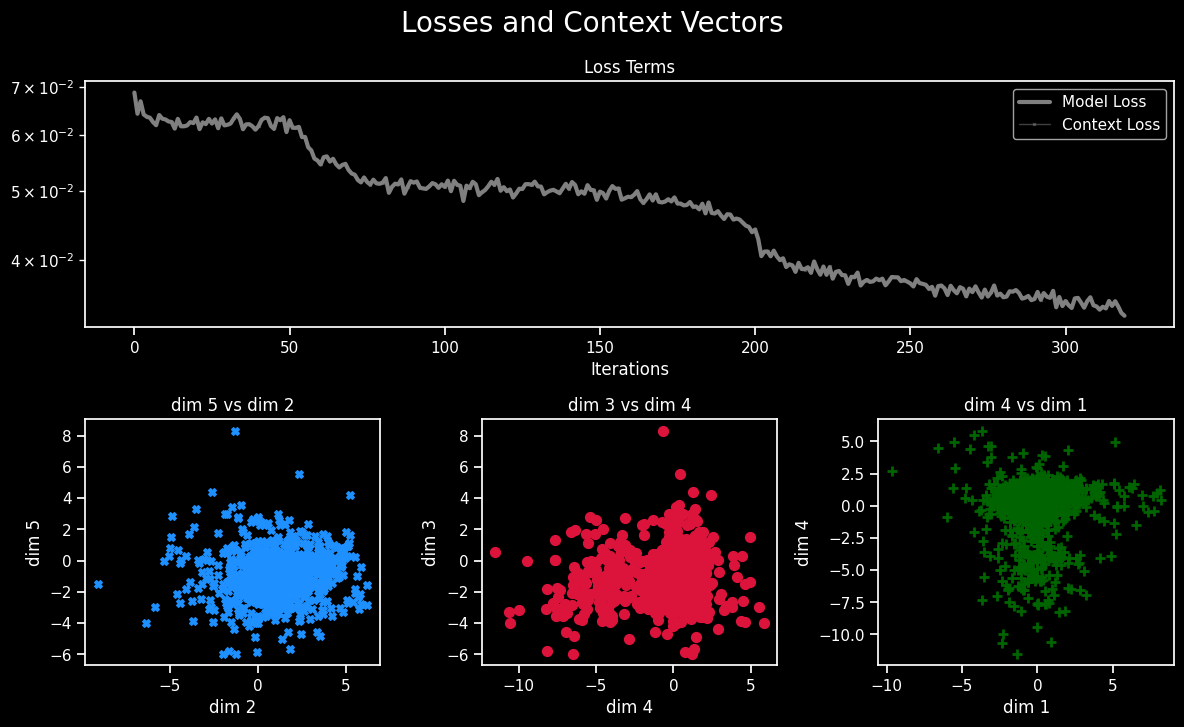

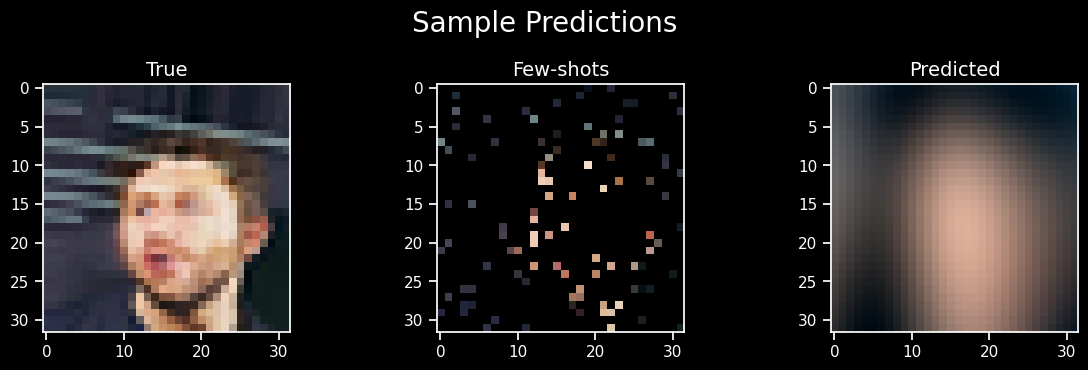

In [ ]:
#%%

## Test and visualise the results on a test dataloader
visualtester = CelebAVisualTester(trainer, key=test_key)

ind_crit, _ = visualtester.evaluate(val_dataloader)        ## TODO: Use val_dataloader
# print("In domain test error:", ind_crit)

all_shots_dataloader = CelebADataLoader(data_folder, 
                                        envs_batch_size=envs_batch_size, 
                                        shots_batch_size=np.prod(resolution), 
                                        data_split="train",
                                        envs_shuffle=True, 
                                        shots_shuffle=True, 
                                        order_pixels=False, 
                                        key=data_key)

visualtester.visualizeArtefacts(save_path=run_folder+"artefacts.png")

visualtester.visualizeFewShots(few_shots_loader=train_dataloader,
                                all_shots_loader=all_shots_dataloader,
                                save_path=run_folder+"few_shots_ind.png",
                                key=jax.random.PRNGKey(time.time_ns())
                             );

In [ ]:
#%%

## Adapt the model to the new dataset
if meta_test:
    adapt_dataloader = CelebADataLoader(data_folder, 
                                        envs_batch_size=envs_batch_size, 
                                        shots_batch_size=k_shots, 
                                        data_split="test",
                                        key=data_key)

    opt_adapt = optax.adabelief(init_lr_ctx)

    _, contexts, aux_data = trainer.meta_test(adapt_dataloader,
                                            nb_inner_steps=nb_inner_steps[1],
                                            taylor_order=taylor_orders[1],
                                            optimizer=opt_adapt, 
                                            max_adapt_batches=max_train_batches,     ## JUST to set up adaptation for future tasks
                                            print_error_every=print_error_every, 
                                            save_path=adapt_folder)

    ood_crit, _ = visualtester.evaluate(adapt_dataloader, 
                                        taylor_order=taylor_orders[1], 
                                        nb_inner_steps=nb_inner_steps[1])



=== Beginning adaptation ... ===
    Number of environment batches: 20
    Number of envs train steps per batch: 50
    Total number of training steps: 1000
     ### (Re)Compiling function "adapt_step" for context ... 
    Batch ID:   0     Loss: 0.03664453        OtherNorms: [0.00630186 0.03504686 1.591363  ]
    Batch ID:   1     Loss: 0.03653333        OtherNorms: [0.00630186 0.03495897 1.5680568 ]
    Batch ID:   2     Loss: 0.03633302        OtherNorms: [0.00630186 0.03475895 1.5677752 ]
    Batch ID:   3     Loss: 0.03611615        OtherNorms: [0.00630186 0.03454887 1.5609761 ]
    Batch ID:   4     Loss: 0.03760439        OtherNorms: [0.00630186 0.03602533 1.5727599 ]
    Batch ID:   5     Loss: 0.03613272        OtherNorms: [0.00630186 0.03455164 1.5747883 ]
    Batch ID:   6     Loss: 0.03641456        OtherNorms: [0.00630186 0.03482357 1.584692  ]
    Batch ID:   7     Loss: 0.03540054        OtherNorms: [0.00630186 0.03386675 1.5274811 ]
    Batch ID:   8     Loss: 0.03716

==  Begining artefacts visualisation ... ==
    Visualized context dimensions along x: [2 4 1]
    Visualized context dimensions along y: [5 3 4]
Saving artefacts in: ./runs/240617-190219/adapt/artefacts.png
==  Begining in-domain CelebA visualisation ... ==
    Environment batch id: 11
Saving visualization in: ./runs/240617-190219/adapt/few_shots_ood.png


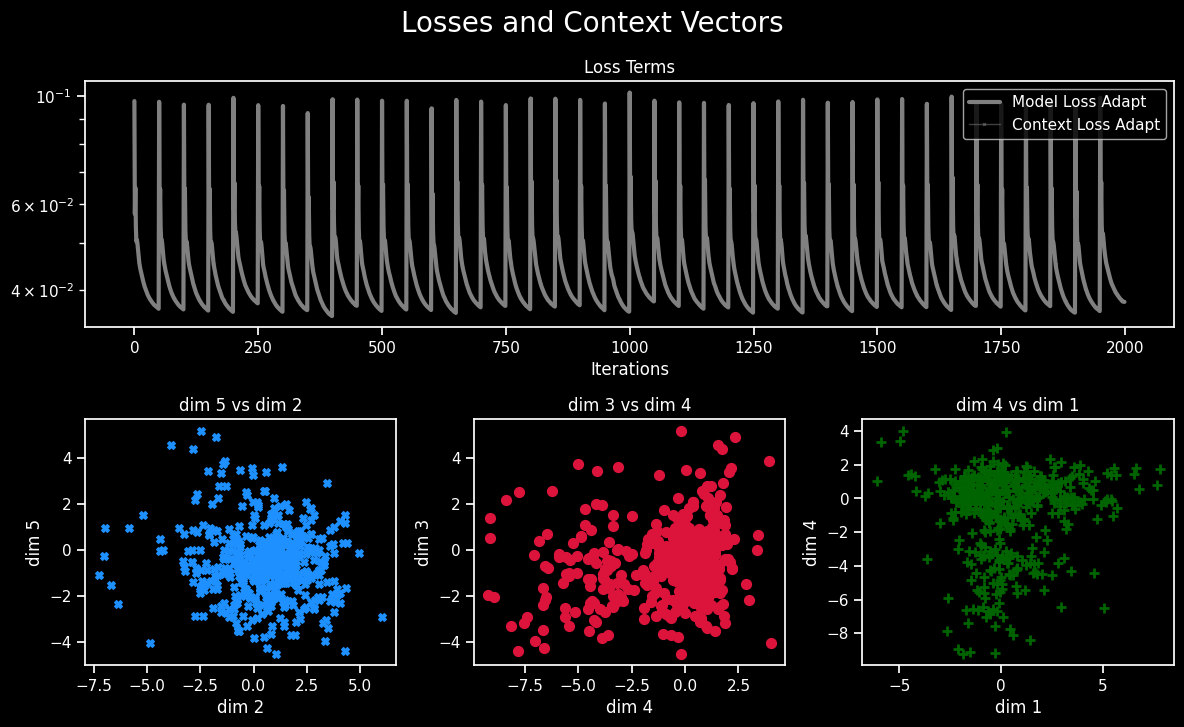

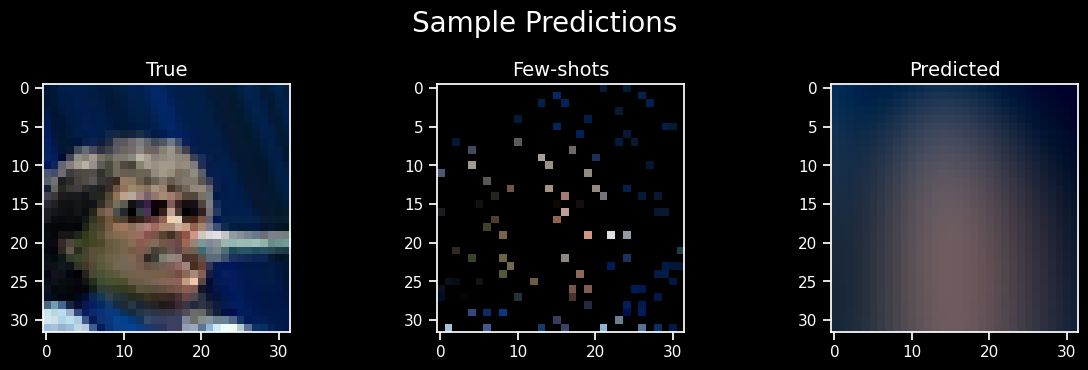

In [ ]:
#%%

## Visualise the adaptation results

if meta_test:
    all_shots_loader = CelebADataLoader(data_folder, 
                                        envs_batch_size=envs_batch_size, 
                                        shots_batch_size=np.prod(resolution), 
                                        data_split="test",
                                        key=data_key)

    visualtester.visualizeArtefacts(save_path=adapt_folder+"artefacts.png", adaptation=True)

    visualtester.visualizeFewShots(few_shots_loader=adapt_dataloader,
                                all_shots_loader=all_shots_loader,
                                nb_inner_steps=nb_inner_steps[1],
                                save_path=adapt_folder+"few_shots_ood.png",
                                key=jax.random.PRNGKey(time.time_ns())
                                );

In [ ]:
#%%

# learner.contexts_adapt

In [ ]:
#%%

# ## Let's investigate the model

# model = trainer.learner.model

# print(model)

# losses, contexts, aux_data

# X, Y, Y_hat = aux_data

# print(Y_hat[5])




# fig, ax = plt.subplot_mosaic('A', figsize=(4*1, 3.7*1))
# img_size = (32, 32, 3)

# def make_image(xy_coords, rgb_pixels):
#     img = np.zeros(img_size)
#     x_coords = (xy_coords[:, 0] * img_size[0]).astype(int)
#     y_coords = (xy_coords[:, 1] * img_size[1]).astype(int)
#     img[x_coords, y_coords, :] = np.clip(rgb_pixels, 0., 1.)
#     return img

# X_plot, Y_plot, Y_hat_plot = X[0], Y[0], Y_hat[0]
# true_img = make_image(X_plot, Y_hat_plot)
# ax['A'].imshow(true_img)
# ax['A'].set_title('Test', fontsize=14)

In [ ]:
#%%

## After training, copy nohup.log to the runfolder
try:
    __IPYTHON__ ## in a jupyter notebook
except NameError:
    if os.path.exists("nohup.log"):
        os.system(f"cp nohup.log {run_folder}")